## Классификация рецензий: текстовая DL-модель (BPE + LSTM + Attention + Linear)

### Настройка

Импорты + конфигурация:

In [2]:
import os
import random
from collections import Counter
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import youtokentome as yttm

device = torch.device("mps" if torch.mps.is_available() else "cpu")

DATA_PATH = "dataset.csv"

TEST_SIZE = 0.15
VAL_SIZE = 0.15
RANDOM_STATE = 42

VOCAB_SIZE = 10000
PAD_ID = 0
UNK_ID = 1
BOS_ID = -1
EOS_ID = -1
MAX_LEN_TOKENS = 800

EMB_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = 3

BATCH_SIZE = 32
N_EPOCHS = 8
LR = 1e-3

BPE_CORPUS_PATH = "bpe_corpus.txt"
BPE_MODEL_PATH = "bpe_model.bin"

### EDA

Информация о датасете:

In [4]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print(df.isna().sum())

Shape: (4539, 6)
reviewer      0
date          0
likes         0
score         0
label_3cls    0
review        0
dtype: int64


Распределение score и классов:

In [8]:
print("\nScore stats:")
print(df["score"].describe())

print("\nLabel distribution:")
print(df["label_3cls"].value_counts())


Score stats:
count    4539.000000
mean       74.287508
std        13.198737
min         9.000000
25%        68.000000
50%        78.000000
75%        83.000000
max        90.000000
Name: score, dtype: float64

Label distribution (counts):
label_3cls
1    1580
0    1553
2    1406
Name: count, dtype: int64


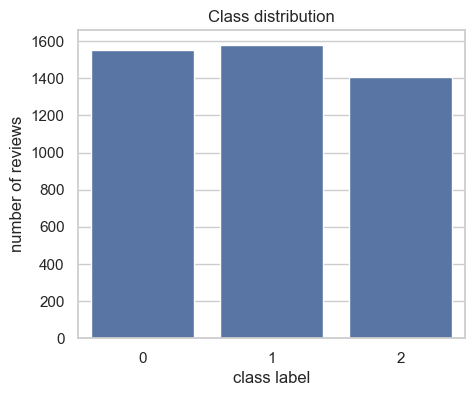

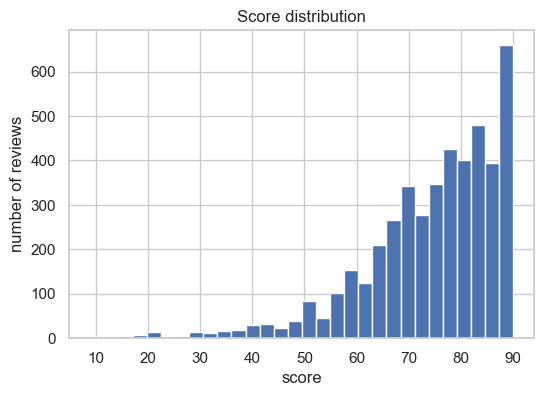

In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x="label_3cls", data=df)
plt.title("Class distribution")
plt.xlabel("class label")
plt.ylabel("number of reviews")
plt.show()

plt.figure(figsize=(6, 4))
df["score"].hist(bins=30)
plt.title("Score distribution")
plt.xlabel("score")
plt.ylabel("number of reviews")
plt.show()

Длины текстов и их распределение:

count    4539.000000
mean      206.637585
std       200.702797
min        38.000000
25%        85.000000
50%       139.000000
75%       257.000000
max      1421.000000
Name: n_words, dtype: float64


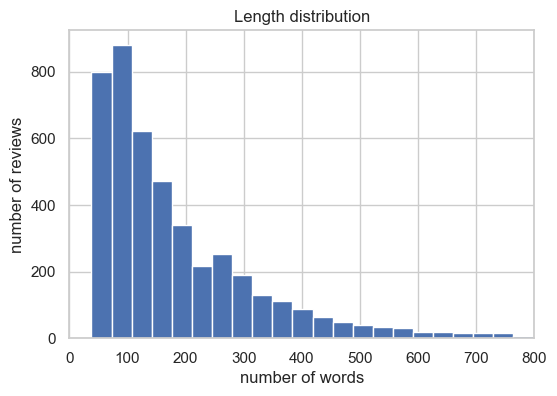

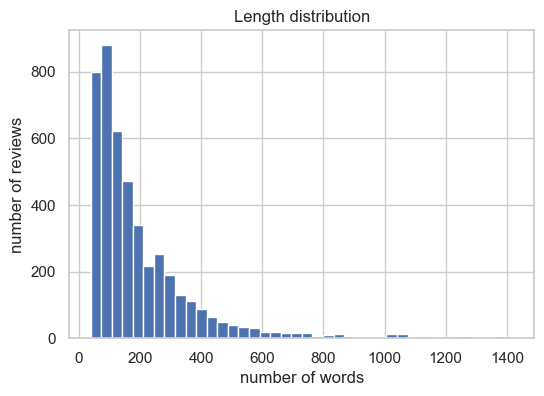

In [14]:
df["n_words"] = df["review"].astype(str).str.split().str.len()
print(df["n_words"].describe())

plt.figure(figsize=(6, 4))
df["n_words"].hist(bins=40)
plt.title("Length distribution")
plt.xlabel("number of words")
plt.ylabel("number of reviews")
plt.xlim(0, 800)
plt.show()

plt.figure(figsize=(6, 4))
df["n_words"].hist(bins=40)
plt.title("Length distribution")
plt.xlabel("number of words")
plt.ylabel("number of reviews")
plt.show()

### Разбиение

Train/val/test с стратификацией:

In [5]:
X = df["review"].astype(str).values
y = df["label_3cls"].values

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

val_rel = VAL_SIZE / (1.0 - TEST_SIZE)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_rel,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 3177
Val size: 681
Test size: 681


### Препроцесинг + BPE

Препроцессинг текста:

In [8]:
def preprocess(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"[^а-яa-z0-9.,!?«»\"'()\\-–—% ]+", " ", text)
    text = " ".join(text.split())
    return text

Препроцессинг корпуса + обучение и загрузка BPE:

In [9]:
with open(BPE_CORPUS_PATH, "w", encoding="utf-8") as f:
    for t in X_train:
        f.write(preprocess(t) + "\n")

if not os.path.exists(BPE_MODEL_PATH):
    yttm.BPE.train(
        data=BPE_CORPUS_PATH,
        vocab_size=VOCAB_SIZE,
        model=BPE_MODEL_PATH,
        pad_id=PAD_ID,
        unk_id=UNK_ID,
        bos_id=BOS_ID,
        eos_id=EOS_ID,
    )

bpe = yttm.BPE(model=BPE_MODEL_PATH)

Длина BPE-последовательностей и выбор MAX_LEN_TOKENS:

In [10]:
lengths = []
for t in X_train:
    ids = bpe.encode([preprocess(t)], output_type=yttm.OutputType.ID)[0]
    lengths.append(len(ids))

lengths = np.array(lengths)
print("BPE lengths train stats:")
print(f"mean: {lengths.mean()}")
print(f"95%: {np.percentile(lengths, 95)}")
print(f"99%: {np.percentile(lengths, 99)}")
print(f"max: {lengths.max()}")

BPE lengths train stats:
mean: 259.0358829084042
95%: 762.0
99%: 1421.7999999999956
max: 2012


Из анализа выше можно сказать, что MAX_LEN_TOKENS = 800 и будет покрывать ~95% текстов полностью.

Перевод текста в id фиксированной длины:

In [11]:
def encode_bpe_batch(texts, max_len: int = MAX_LEN_TOKENS):
    all_ids = []
    for t in texts:
        ids = bpe.encode([preprocess(t)], output_type=yttm.OutputType.ID)[0]
        ids = ids[:max_len]
        if len(ids) < max_len:
            ids = ids + [PAD_ID] * (max_len - len(ids))
        all_ids.append(ids)
    return np.array(all_ids)


X_train_ids = encode_bpe_batch(X_train)
X_val_ids = encode_bpe_batch(X_val)
X_test_ids  = encode_bpe_batch(X_test)

print(f"Train ids: {X_train_ids.shape}")
print(f"Val ids: {X_val_ids.shape}")
print(f"Test ids: {X_test_ids.shape}")

Train ids: (3177, 800)
Val ids: (681, 800)
Test ids: (681, 800)


### Dataset + DataLoader

In [27]:
class ReviewsDataset(Dataset):
    def __init__(self, X_ids, y):
        self.X_ids = torch.from_numpy(X_ids).long()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ids[idx], self.y[idx]


train_dataset = ReviewsDataset(X_train_ids, y_train)
val_dataset = ReviewsDataset(X_val_ids, y_val)
test_dataset  = ReviewsDataset(X_test_ids, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Embedding + LSTM + Attention + Linear:

In [ ]:
class LSTMAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_classes, pad_idx):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=emb_dim,
            padding_idx=pad_idx,
        )

        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )

        self.dropout = nn.Dropout(0.6)

        self.attn_linear = nn.Linear(hidden_dim * 2, hidden_dim * 2)
        self.attn_vector = nn.Linear(hidden_dim * 2, 1, bias=False)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)

        u = torch.tanh(self.attn_linear(out))
        attn_scores = self.attn_vector(u).squeeze(-1)

        mask = (x == PAD_ID)
        attn_scores = attn_scores.masked_fill(mask, float("-inf"))

        attn_weights = torch.softmax(attn_scores, dim=1)
        attn_weights = attn_weights.unsqueeze(-1)

        context = torch.sum(out * attn_weights, dim=1)

        context = self.dropout(context)
        logits = self.fc(context)
        return logits


model = LSTMAttentionClassifier(
    vocab_size=VOCAB_SIZE,
    emb_dim=EMB_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    pad_idx=PAD_ID,
).to(device)

Loss:

In [ ]:
class_counts = Counter(y_train)

weights = []
for cls_idx in range(NUM_CLASSES):
    weights.append(len(y_train) / (NUM_CLASSES * class_counts[cls_idx]))

class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(),lr=LR)

### Обучение + валидация

In [33]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * y_batch.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += y_batch.size(0)

    return (total_loss / total), (correct / total)


def eval_model(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * y_batch.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return (total_loss / total), (correct / total), np.array(all_preds), np.array(all_labels)

Обучение и оценка на test:

In [43]:
best_val_acc = 0.0
best_model_path = "best_lstm_attention.pt"

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_loss, val_acc, _, _ = eval_model(
        model, val_loader, criterion, device
    )

    print(f"\nEpoch {epoch}/{N_EPOCHS}")
    print(f"Train loss: {train_loss:.4f}, acc: {train_acc:.4f}")
    print(f"Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

model.load_state_dict(torch.load(best_model_path, map_location=device))

test_loss, test_acc, y_pred_test, y_true_test = eval_model(
    model, test_loader, criterion, device
)

print(f"Test accuracy: {round(test_acc, 4)}")
print("\nResults:")
print(classification_report(y_true_test, y_pred_test, digits=4))


Epoch 1/8
Train loss: 0.0011, acc: 1.0000
Val loss: 4.0063, acc: 0.5844

Epoch 2/8
Train loss: 0.0199, acc: 0.9946
Val loss: 3.9372, acc: 0.5668

Epoch 3/8
Train loss: 0.0232, acc: 0.9950
Val loss: 3.8646, acc: 0.5742

Epoch 4/8
Train loss: 0.0120, acc: 0.9962
Val loss: 3.7745, acc: 0.5727

Epoch 5/8
Train loss: 0.0051, acc: 0.9994
Val loss: 4.1207, acc: 0.5668

Epoch 6/8
Train loss: 0.0062, acc: 0.9987
Val loss: 4.2719, acc: 0.5565

Epoch 7/8
Train loss: 0.0072, acc: 0.9975
Val loss: 4.1674, acc: 0.5727

Epoch 8/8
Train loss: 0.0079, acc: 0.9972
Val loss: 4.5907, acc: 0.5580
Test accuracy: 0.5668

Results:
              precision    recall  f1-score   support

           0     0.6820    0.6352    0.6578       233
           1     0.4444    0.5570    0.4944       237
           2     0.6347    0.5024    0.5608       211

    accuracy                         0.5668       681
   macro avg     0.5871    0.5648    0.5710       681
weighted avg     0.5847    0.5668    0.5709       681



### Выводы

Результаты сравнивал с бейзлайн-моделью (TF-IDF + логистическая регрессия), где метрики были чуть выше.
Разница небольшая, но бейзлайн получился лучше.

Скорее всего это связано с объемом моего датасета. Для лог. регрессии это достаточно, а для DL-модели нет.

В этой задаче слова сами по себе довольно хорошо разделяют классы.
И, если юзер ставит высокую или низкую оценку, это почти всегда видно по лексике. TF-IDF как раз и учитывает, какие слова и как часто встречаются, и для такой задачи этого хватает.